# Modélisation — Prédiction du risque d'annulation
**Maeva — Mastère DIA Paris**

Feature engineering → 3 modèles (Régression Logistique, Random Forest, XGBoost) → évaluation → SHAP.

Stratégie en **2 temps** :
1. **Modèle global** sur tous les dossiers (porté par les variables structurelles)
2. **Modèle ciblé** sur le sous-ensemble CRM (`est_dans_crm=1`) pour mesurer l'apport réel de l'email

---

## 0. Installation (une seule fois)

In [4]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib

## 1. Imports

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, precision_score,
                             recall_score)
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## 2. Chargement

In [6]:
CSV_PATH = 'data/dataset.csv'   # version anonymisée (sans email)
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f'{df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Taux annulation : {df["y_annulation"].mean()*100:.2f}%')

345,093 lignes x 40 colonnes
Taux annulation : 9.76%


In [7]:
conditions_maeva = ['Flexi', 'Flexi+', 'NoFlex', 'NoFlex (<J30)']
df = df[df['cond_annulation'].isin(conditions_maeva)].copy()
print(f'{len(df):,} dossiers après filtre Maeva')
print(f'Taux annulation : {df["y_annulation"].mean()*100:.2f}%')

299,998 dossiers après filtre Maeva
Taux annulation : 7.17%


## 3. Feature engineering — définition des variables
On exclut les identifiants, la cible et les champs post-confirmation (anti-fuite).

In [8]:
# Colonnes à NE PAS utiliser comme features
EXCLURE = ['dossier_cle', 'client_email', 'date_resa',
           'dossier_etat', 'dossier_annule', 'y_annulation',
           'est_dans_crm']   # flag servant au sous-ensemble, pas une feature

# Features numériques candidates
FEATURES_NUM = [
    'anticipation_jours', 'duree_sejour',
    'dossier_nb_pax_total', 'dossier_nb_pax_adultes', 'nb_mineur', 'nb_bebe',
    'mois_resa', 'jour_semaine_resa',
    'nb_clics_90j', 'nb_ouvertures_90j', 'nb_desabo_90j',
    'nb_campagnes_recues', 'nb_campagnes_cliquees',
    'nb_urls_distinctes_cliquees', 'taux_clic_sur_ouverture',
    'a_interagi_email', 'recence_email_jours',
    'nb_dossiers_anterieurs', 'est_client_vip',
    'est_assure_annulation'
]

# Features catégorielles candidates
FEATURES_CAT = [
    'canal', 'groupe_fournisseur', 'periode_depart', 'periode_vacances',
    'type_produit', 'device_resa', 'theme_station', 'region_destination',
    'type_hebergement', 'segment_email', 'cond_annulation'
]

# On ne garde que les colonnes réellement présentes
FEATURES_NUM = [c for c in FEATURES_NUM if c in df.columns and c not in EXCLURE]
FEATURES_CAT = [c for c in FEATURES_CAT if c in df.columns and c not in EXCLURE]

print(f'Features numériques   ({len(FEATURES_NUM)}) : {FEATURES_NUM}')
print(f'\nFeatures catégorielles ({len(FEATURES_CAT)}) : {FEATURES_CAT}')

Features numériques   (20) : ['anticipation_jours', 'duree_sejour', 'dossier_nb_pax_total', 'dossier_nb_pax_adultes', 'nb_mineur', 'nb_bebe', 'mois_resa', 'jour_semaine_resa', 'nb_clics_90j', 'nb_ouvertures_90j', 'nb_desabo_90j', 'nb_campagnes_recues', 'nb_campagnes_cliquees', 'nb_urls_distinctes_cliquees', 'taux_clic_sur_ouverture', 'a_interagi_email', 'recence_email_jours', 'nb_dossiers_anterieurs', 'est_client_vip', 'est_assure_annulation']

Features catégorielles (11) : ['canal', 'groupe_fournisseur', 'periode_depart', 'periode_vacances', 'type_produit', 'device_resa', 'theme_station', 'region_destination', 'type_hebergement', 'segment_email', 'cond_annulation']


In [9]:
# Limiter la cardinalité des catégorielles très éclatées (region, periode...)
# pour éviter une explosion du one-hot : on regroupe les modalités rares en 'autre'
def limiter_cardinalite(data, cols, top_n=20):
    data = data.copy()
    for c in cols:
        top = data[c].value_counts().nlargest(top_n).index
        data[c] = data[c].where(data[c].isin(top), other='autre').astype(str)
    return data

df = limiter_cardinalite(df, FEATURES_CAT, top_n=20)
print('Cardinalité limitée à 20 modalités max par variable catégorielle.')
for c in FEATURES_CAT:
    print(f'  {c:22s}: {df[c].nunique()} modalités')

Cardinalité limitée à 20 modalités max par variable catégorielle.
  canal                 : 14 modalités
  groupe_fournisseur    : 9 modalités
  periode_depart        : 12 modalités
  periode_vacances      : 1 modalités
  type_produit          : 1 modalités
  device_resa           : 3 modalités
  theme_station         : 5 modalités
  region_destination    : 21 modalités
  type_hebergement      : 10 modalités
  segment_email         : 6 modalités
  cond_annulation       : 4 modalités


## 4. Pipeline de préprocessing & fonction d'entraînement
Une fonction réutilisable pour lancer les 3 modèles sur n'importe quel sous-ensemble.

In [10]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='inconnu')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])

def get_feature_names(preprocessor, num_cols, cat_cols):
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    return num_cols + cat_names

In [11]:
def evaluer(nom, model, Xtr, ytr, Xte, yte, seuil=0.5):
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= seuil).astype(int)
    res = {
        'nom': nom, 'model': model, 'proba': proba, 'pred': pred,
        'auc': roc_auc_score(yte, proba),
        'ap': average_precision_score(yte, proba),   # PR-AUC, clé en déséquilibre
        'f1': f1_score(yte, pred),
        'precision': precision_score(yte, pred),
        'recall': recall_score(yte, pred)
    }
    print(f"\n{'='*48}\n  {nom}\n{'='*48}")
    print(f"  AUC-ROC   : {res['auc']:.4f}")
    print(f"  PR-AUC    : {res['ap']:.4f}   (référence = {yte.mean():.4f})")
    print(f"  F1        : {res['f1']:.4f}")
    print(f"  Précision : {res['precision']:.4f}")
    print(f"  Rappel    : {res['recall']:.4f}")
    return res

In [12]:
def run_pipeline(data, num_cols, cat_cols, label=''):
    """Split + préprocessing + 3 modèles. Retourne tout le nécessaire."""
    X = data[num_cols + cat_cols]
    y = data['y_annulation'].astype(int)

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

    prep = build_preprocessor(num_cols, cat_cols)
    Xtr_p = prep.fit_transform(Xtr)
    Xte_p = prep.transform(Xte)
    feat_names = get_feature_names(prep, num_cols, cat_cols)

    print(f'\n### PÉRIMÈTRE : {label} ###')
    print(f'Train {Xtr.shape[0]:,} | Test {Xte.shape[0]:,} | '
          f'Taux Y=1 train {ytr.mean()*100:.2f}% | features après OHE : {len(feat_names)}')

    # Poids pour le déséquilibre
    spw = (ytr == 0).sum() / (ytr == 1).sum()

    results = []
    results.append(evaluer('Régression Logistique', LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        Xtr_p, ytr, Xte_p, yte))
    results.append(evaluer('Random Forest', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        Xtr_p, ytr, Xte_p, yte))
    results.append(evaluer('XGBoost', XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_STATE),
        Xtr_p, ytr, Xte_p, yte))

    return {'results': results, 'prep': prep, 'feat_names': feat_names,
            'Xte_p': Xte_p, 'yte': yte, 'label': label}

## 5. TEMPS 1 — Modèle global (tous les dossiers)

In [ ]:
glob = run_pipeline(df, FEATURES_NUM, FEATURES_CAT, label='GLOBAL (tous dossiers)')


### PÉRIMÈTRE : GLOBAL (tous dossiers) ###
Train 209,998 | Test 90,000 | Taux Y=1 train 7.17% | features après OHE : 106

  Régression Logistique
  AUC-ROC   : 0.7124
  PR-AUC    : 0.1884   (référence = 0.0717)
  F1        : 0.2131
  Précision : 0.1270
  Rappel    : 0.6629


In [ ]:
# Tableau récapitulatif
def recap(res_list):
    return (pd.DataFrame([{'Modèle': r['nom'], 'AUC-ROC': round(r['auc'],4),
                           'PR-AUC': round(r['ap'],4), 'F1': round(r['f1'],4),
                           'Précision': round(r['precision'],4),
                           'Rappel': round(r['recall'],4)} for r in res_list])
            .sort_values('PR-AUC', ascending=False).reset_index(drop=True))

recap_glob = recap(glob['results'])
print('=== RÉCAP MODÈLE GLOBAL ===')
recap_glob

=== RÉCAP MODÈLE GLOBAL ===


,Modèle,AUC-ROC,PR-AUC,F1,Précision,Rappel
0,XGBoost,0.8231,0.4318,0.3839,0.2663,0.6876
1,Random Forest,0.8044,0.3831,0.3715,0.2622,0.6371
2,Régression Logistique,0.7808,0.3666,0.3361,0.2271,0.6467


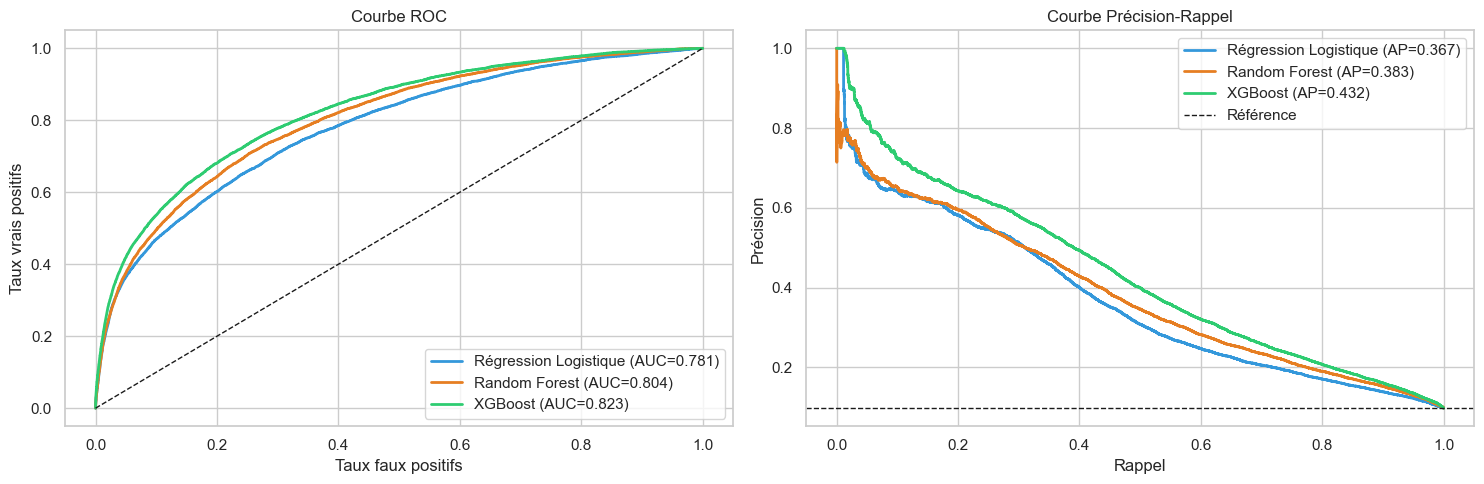

In [ ]:
# Courbes ROC + Precision-Recall (la PR est plus parlante en déséquilibre)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']
for r, c in zip(glob['results'], colors):
    fpr, tpr, _ = roc_curve(glob['yte'], r['proba'])
    ax1.plot(fpr, tpr, color=c, lw=2, label=f"{r['nom']} (AUC={r['auc']:.3f})")
    prec, rec, _ = precision_recall_curve(glob['yte'], r['proba'])
    ax2.plot(rec, prec, color=c, lw=2, label=f"{r['nom']} (AP={r['ap']:.3f})")
ax1.plot([0,1],[0,1],'k--',lw=1); ax1.set_title('Courbe ROC'); ax1.legend(loc='lower right')
ax1.set_xlabel('Taux faux positifs'); ax1.set_ylabel('Taux vrais positifs')
ax2.axhline(glob['yte'].mean(), ls='--', c='k', lw=1, label='Référence')
ax2.set_title('Courbe Précision-Rappel'); ax2.legend(loc='upper right')
ax2.set_xlabel('Rappel'); ax2.set_ylabel('Précision')
plt.tight_layout(); plt.savefig('figures/11_courbes_global.png', dpi=150); plt.show()

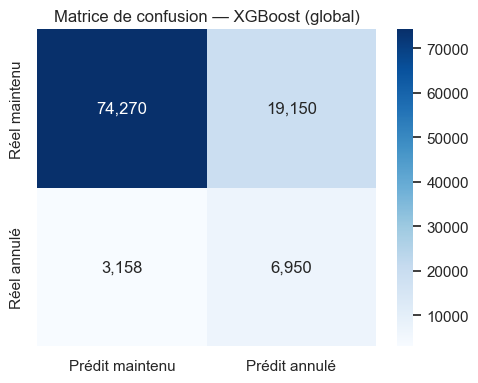

              precision    recall  f1-score   support

    Maintenu       0.96      0.80      0.87     93420
      Annulé       0.27      0.69      0.38     10108

    accuracy                           0.78    103528
   macro avg       0.61      0.74      0.63    103528
weighted avg       0.89      0.78      0.82    103528



In [ ]:
# Matrice de confusion du meilleur modèle (XGBoost)
best = [r for r in glob['results'] if r['nom']=='XGBoost'][0]
cm = confusion_matrix(glob['yte'], best['pred'])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit maintenu','Prédit annulé'],
            yticklabels=['Réel maintenu','Réel annulé'], ax=ax)
ax.set_title('Matrice de confusion — XGBoost (global)')
plt.tight_layout(); plt.savefig('figures/12_confusion_global.png', dpi=150); plt.show()
print(classification_report(glob['yte'], best['pred'],
      target_names=['Maintenu','Annulé']))

## 6. Interprétabilité SHAP (XGBoost global)

In [ ]:
import re

# Nettoyage des noms de features : XGBoost interdit [ ] 
def clean_names(names):
    return [re.sub(r'[\[\]<>]', '_', str(n)) for n in names]

feat_names_clean = clean_names(glob['feat_names'])

# Échantillon pour accélérer SHAP
Xte_df = pd.DataFrame(glob['Xte_p'], columns=feat_names_clean)
n_shap = min(3000, len(Xte_df))
Xte_sample = Xte_df.sample(n_shap, random_state=RANDOM_STATE)

# IMPORTANT : le modèle a été entraîné sur des noms non nettoyés.
# On neutralise la vérification des noms côté booster.
best['model'].get_booster().feature_names = None

explainer = shap.TreeExplainer(best['model'])
shap_values = explainer.shap_values(Xte_sample)
print(f'SHAP calculé sur {n_shap:,} dossiers')

SHAP calculé sur 3,000 dossiers


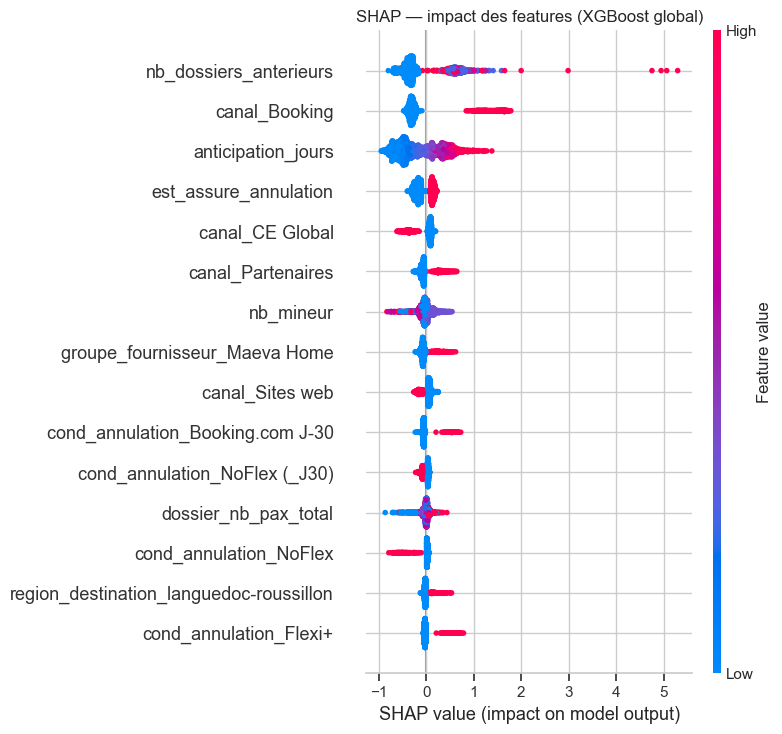

In [ ]:

# Importance globale (beeswarm)
plt.figure()
shap.summary_plot(shap_values, Xte_sample, max_display=15, show=False)
plt.title('SHAP — impact des features (XGBoost global)')
plt.tight_layout(); plt.savefig('figures/13_shap_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()

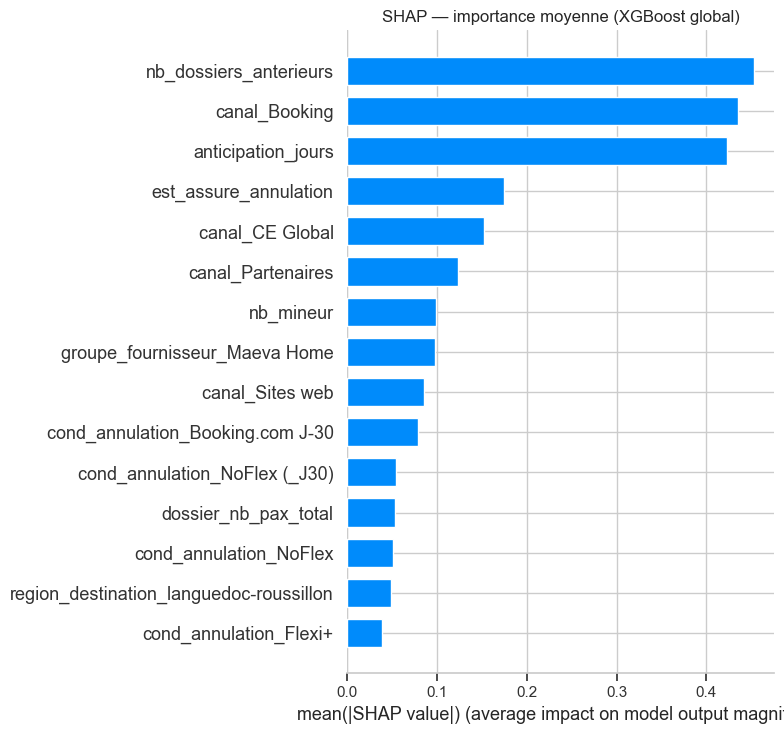

In [ ]:
# Importance moyenne (barres)
plt.figure()
shap.summary_plot(shap_values, Xte_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — importance moyenne (XGBoost global)')
plt.tight_layout(); plt.savefig('figures/14_shap_bar.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. ★ TEMPS 2 — Modèle ciblé sur le sous-ensemble CRM
On ne garde que les dossiers ayant un historique email (`est_dans_crm=1`).
Sur cette population, les features email ont enfin de la variance : on mesure leur apport réel.

In [ ]:
df_crm = df[df['est_dans_crm'] == 1].copy()
print(f'Sous-ensemble CRM : {len(df_crm):,} dossiers '
      f'(taux annulation {df_crm["y_annulation"].mean()*100:.2f}%)')

crm = run_pipeline(df_crm, FEATURES_NUM, FEATURES_CAT, label='SOUS-ENSEMBLE CRM (est_dans_crm=1)')
recap_crm = recap(crm['results'])
print('=== RÉCAP MODÈLE CRM ===')
recap_crm

Sous-ensemble CRM : 31,028 dossiers (taux annulation 6.41%)

### PÉRIMÈTRE : SOUS-ENSEMBLE CRM (est_dans_crm=1) ###
Train 21,719 | Test 9,309 | Taux Y=1 train 6.41% | features après OHE : 107

  Régression Logistique
  AUC-ROC   : 0.7347
  PR-AUC    : 0.1676   (référence = 0.0640)
  F1        : 0.2165
  Précision : 0.1283
  Rappel    : 0.6946

  Random Forest
  AUC-ROC   : 0.7657
  PR-AUC    : 0.2190   (référence = 0.0640)
  F1        : 0.2517
  Précision : 0.1624
  Rappel    : 0.5587

  XGBoost
  AUC-ROC   : 0.7553
  PR-AUC    : 0.2421   (référence = 0.0640)
  F1        : 0.2830
  Précision : 0.2028
  Rappel    : 0.4681
=== RÉCAP MODÈLE CRM ===


,Modèle,AUC-ROC,PR-AUC,F1,Précision,Rappel
0,XGBoost,0.7553,0.2421,0.2830,0.2028,0.4681
1,Random Forest,0.7657,0.2190,0.2517,0.1624,0.5587
2,Régression Logistique,0.7347,0.1676,0.2165,0.1283,0.6946


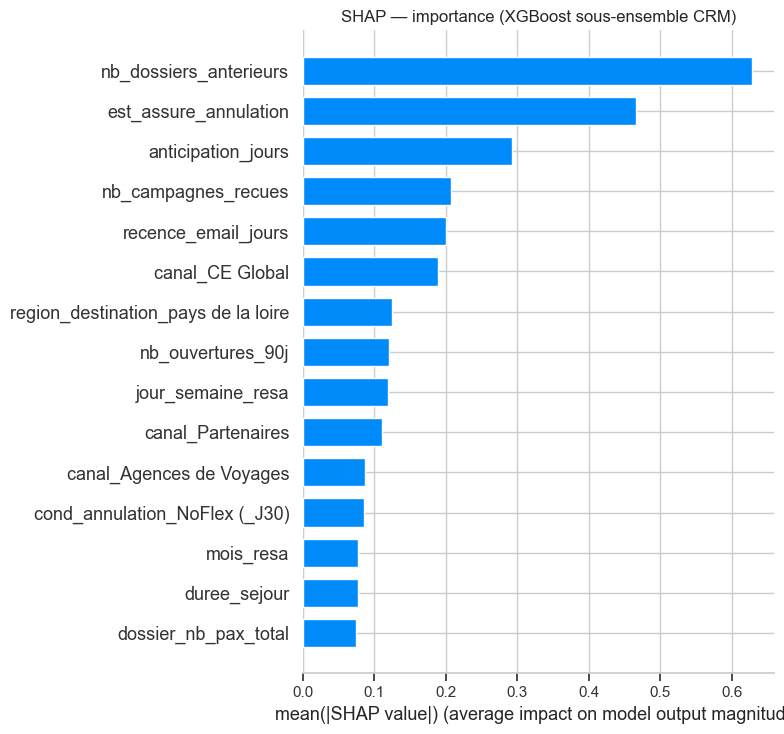

In [ ]:
import re
def clean_names(names):
    return [re.sub(r'[\[\]<>]', '_', str(n)) for n in names]

best_crm = [r for r in crm['results'] if r['nom']=='XGBoost'][0]
feat_names_crm_clean = clean_names(crm['feat_names'])
Xte_crm_df = pd.DataFrame(crm['Xte_p'], columns=feat_names_crm_clean)
n2 = min(3000, len(Xte_crm_df))
Xte_crm_s = Xte_crm_df.sample(n2, random_state=RANDOM_STATE)

best_crm['model'].get_booster().feature_names = None

expl_crm = shap.TreeExplainer(best_crm['model'])
sv_crm = expl_crm.shap_values(Xte_crm_s)

plt.figure()
shap.summary_plot(sv_crm, Xte_crm_s, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — importance (XGBoost sous-ensemble CRM)')
plt.tight_layout(); plt.savefig('figures/15_shap_crm.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Comparaison Global vs CRM

In [ ]:
comp = pd.DataFrame({
    'Périmètre': ['Global', 'Sous-ensemble CRM'],
    'N dossiers': [len(df), len(df_crm)],
    'Taux annul. (%)': [round(df['y_annulation'].mean()*100,2),
                        round(df_crm['y_annulation'].mean()*100,2)],
    'XGB AUC-ROC': [round([r for r in glob['results'] if r['nom']=='XGBoost'][0]['auc'],4),
                    round(best_crm['auc'],4)],
    'XGB PR-AUC': [round([r for r in glob['results'] if r['nom']=='XGBoost'][0]['ap'],4),
                   round(best_crm['ap'],4)]
})
print('=== COMPARAISON DES DEUX PÉRIMÈTRES ===')
comp

=== COMPARAISON DES DEUX PÉRIMÈTRES ===


,Périmètre,N dossiers,Taux annul. (%),XGB AUC-ROC,XGB PR-AUC
0,Global,345093,9.76,0.8231,0.4318
1,Sous-ensemble CRM,31028,6.41,0.7553,0.2421


## 9. Export du modèle final (global)

In [ ]:
joblib.dump(best['model'], 'models/xgb_annulation.joblib')
joblib.dump(glob['prep'], 'models/preprocessor.joblib')
joblib.dump({'features_num': FEATURES_NUM, 'features_cat': FEATURES_CAT,
             'feat_names_ohe': glob['feat_names']}, 'models/features_config.joblib')
print('Modèle exporté dans ./models/ :')
print('  - xgb_annulation.joblib')
print('  - preprocessor.joblib')
print('  - features_config.joblib')

Modèle exporté dans ./models/ :
  - xgb_annulation.joblib
  - preprocessor.joblib
  - features_config.joblib


In [ ]:
# Vérification du rechargement
m = joblib.load('models/xgb_annulation.joblib')
p = joblib.load('models/preprocessor.joblib')
sample = df[FEATURES_NUM + FEATURES_CAT].iloc[[0]]
score = m.predict_proba(p.transform(sample))[0][1]
print(f'Rechargement OK — score du 1er dossier : {score:.4f} ({score*100:.1f}% de risque d\'annulation)')

Rechargement OK — score du 1er dossier : 0.2748 (27.5% de risque d'annulation)


## 10. Synthèse

In [ ]:
print('='*55)
print('  SYNTHÈSE MODÉLISATION')
print('='*55)
print('\nMODÈLE GLOBAL :')
print(recap_glob.to_string(index=False))
print('\nMODÈLE CRM :')
print(recap_crm.to_string(index=False))
print('\nÀ analyser dans le mémoire :')
print('  - SHAP global : cond_annulation & canal dominent (attendu)')
print('  - SHAP CRM : les features email remontent-elles dans le top ?')
print('  - PR-AUC > référence = le modèle apporte un vrai gain de ciblage')
print('  Figures dans ./figures/ , modèle dans ./models/')
print('='*55)

  SYNTHÈSE MODÉLISATION

MODÈLE GLOBAL :
               Modèle  AUC-ROC  PR-AUC     F1  Précision  Rappel
              XGBoost   0.8231  0.4318 0.3839     0.2663  0.6876
        Random Forest   0.8044  0.3831 0.3715     0.2622  0.6371
Régression Logistique   0.7808  0.3666 0.3361     0.2271  0.6467

MODÈLE CRM :
               Modèle  AUC-ROC  PR-AUC     F1  Précision  Rappel
              XGBoost   0.7553  0.2421 0.2830     0.2028  0.4681
        Random Forest   0.7657  0.2190 0.2517     0.1624  0.5587
Régression Logistique   0.7347  0.1676 0.2165     0.1283  0.6946

À analyser dans le mémoire :
  - SHAP global : cond_annulation & canal dominent (attendu)
  - SHAP CRM : les features email remontent-elles dans le top ?
  - PR-AUC > référence = le modèle apporte un vrai gain de ciblage
  Figures dans ./figures/ , modèle dans ./models/
